In [1]:
# Trade-off index

In [2]:
import numpy as np
import itertools
import math
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [3]:
def tradeoff_index(XX, ncolor=8, out_clr=None, OFnames=None):
    """
    Python translation of MATLAB function tradeoff_index

    Parameters
    ----------
    XX : ndarray (nsols, nobj)
        Objective values
    ncolor : int
        Number of colors
    out_clr : ndarray or None
        Color palette
    OFnames : list of str or None
        Objective names

    Returns
    -------
    hh : matplotlib.figure.Figure
        Figure handle
    lambdas : ndarray
        Lambda matrices (nrows, nrows, ntradeoffs)
    to_names : list
        Trade-off names
    """

    XX = np.asarray(XX, dtype=float)
    nsols, nobj = XX.shape

    # Objective names
    if OFnames is None or len(OFnames) == 0:
        OFnames = [f"obj{i+1}" for i in range(nobj)]

    # Plot options
    #sel_fontname = "Times"
    sel_fontsize = 6
    sel_fontweight = "normal"
    ndecimals = 3
    strformat = f"%.{ndecimals}f"

    # Rescale objectives to [0,1]
    XX2 = (XX - XX.min(axis=0)) / (XX.max(axis=0) - XX.min(axis=0))

    ntradeoffs = math.comb(nobj, 2)
    nrows = int(np.ceil(np.sqrt(nsols)))
    print(nrows)
    
    lambdas = np.zeros((nrows, nrows, ntradeoffs))

    # Correlations
    rhoes = np.zeros((nobj, nobj))
    pvals = np.zeros((nobj, nobj))
    for i in range(nobj):
        for j in range(nobj):
            rhoes[i, j], pvals[i, j] = pearsonr(XX2[:, i], XX2[:, j])

    # ---- Tradeoff Index estimation ----
    to_names = []
    ito = 0

    for of1 in range(nobj - 1):
        for of2 in range(of1 + 1, nobj):
            ito += 1
            L = np.zeros(nrows * nrows)

            for si in range(nsols):
                beta = np.zeros(nsols)
                for sj in range(nsols):
                    if si != sj:
                        xp = (XX2[si, of1] - XX2[sj, of1]) * \
                             (XX2[si, of2] - XX2[sj, of2])
                        if xp < 0:
                            beta[sj] = 1.0
                L[si] = np.sum(beta) / (nsols - 1)

            lambdas[:, :, ito - 1] = L.reshape((nrows, nrows)).T

            percentage = (np.sum(L) / nsols) * 100
            label = [
                #f"{OFnames[of1]} -> {OFnames[of2]}",
                f"$\\lambda$ :{percentage:3.1f}",
                f"$r = {rhoes[of1, of2]:1.3f}$"
            ]
            
            to_names.append(label)

    # ---- Plotting ----
    hh = plt.figure(figsize=(10.1, 9.1), facecolor="white")
    ax = plt.gca()

    cmap = plt.colormaps['RdBu_r']#, ncolor)
    plt.set_cmap(cmap)
    
    xfalse = (np.arange(nrows) + 0.5) / nrows
    text_size = 18 - nobj
    ito = 0

    for of1 in range(nobj - 1):
        for of2 in range(of1 + 1, nobj):
            ito += 1
            xp = (of2 - 1) + xfalse
            yp = (nobj - (of1 + 2)) + xfalse
            

            X, Y = np.meshgrid(xp, yp)
            Z = lambdas[:, :, ito - 1]
            ax.pcolormesh(X, Y, Z, shading="nearest")

            ax.text(
                np.mean(xp), np.mean(yp),
                "\n".join(to_names[ito - 1]),
                ha = "center", 
                va = "center",
                fontsize   = text_size, #fontname=sel_fontname,
                fontweight = sel_fontweight,
                bbox       = dict(facecolor="white", edgecolor="black")
            )

    # Frame
    ax.plot([0, nobj-1, nobj-1, 0, 0],
            [0, 0, nobj-1, nobj-1, 0],
            "k-", linewidth = 0.5)

    plt.grid(which='both')
    #ax.set_xlim(0, nobj - 1)
    #ax.set_ylim(0, nobj - 1)
    ax.set_xticks(np.arange(0,nobj-1)+0.5)#[0, nobj-1])
    ax.set_yticks(np.arange(0,nobj-1)+0.5)#[0, nobj-1])
    ax.set_xticklabels(OFnames[1:],ha='center')#['', ''])
    ax.set_yticklabels(OFnames[::-1][1:])#['', ''])
    ax.set_aspect("equal")

    ax.set_title(
        'Trade-off Index $\\lambda$ [%]', #fontname=sel_fontname,
        fontsize=sel_fontsize + 6,
        fontweight="bold"
    )

    # Colormap
    if out_clr is None:
        out_clr = create_colors(ncolor)
    
    #cbar = plt.colorbar(
    #    ticks=np.linspace(0, 1, ncolor + 1),
    #    fraction=0.046, pad=0.04)
    #cbar.ax.set_title("$\\lambda$", fontsize=sel_fontsize + 4)

    return hh, lambdas, to_names

In [4]:
def create_colors(ncolor):
    return plt.cm.RdBu_r(np.linspace(0, 1, ncolor))

13


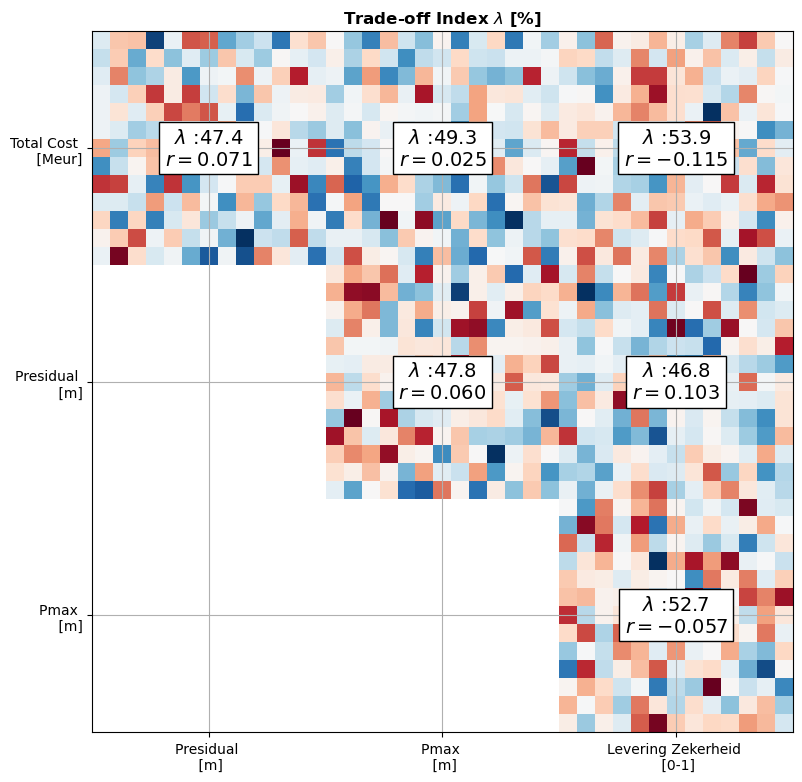

In [5]:
np.random.seed(0)

nobj = 4
if nobj == 3:
    npoints = 169
    x =  np.linspace(0,1,npoints) + 1/10*np.random.rand(npoints)
    XX =  [ x, 1-x,1-x**x] 
    #XX = np.random.rand(169, nobj)
    OFnames = ['linear','trade-off','trade-off 2']
elif nobj == 4:
    XX = np.random.rand(169, nobj)  # 169 solutions, 4 objectives
    OFnames = ['Total Cost \n [Meur]',
           'Presidual \n [m]',
           'Pmax \n [m]',
           'Levering Zekerheid \n [0-1]']
elif nobj == 5:
    XX = np.random.rand(169, nobj)  # 169 solutions, 5 objectives
    OFnames =["Cost \n [$]", "Emissions \n [Ton$CO_2$]", 'Reliability \n [%]', 'Time \n [yr]','Functionality \n [%]']
elif nobj == 10:
    XX = np.random.rand(169, 10)  # 169 solutions, 10 objectives
    OFnames = ['NOISE \n [$dB$]', 'WEMP \n [$10^{3}lb$]', 'DOC \n [$USD/hr$]',
       'ROUGH \n [Ratio]', 'WFUEL \n [$10^{2}lb$]', 'PURCH \n [$10^{3}USD$]',
       'RANGE \n [$10^{3}nmi$]', 'LDMAX \n [Ratio]', 'VCMAX \n [knots]',
       'PFPF \n [Ratio]']

# call tradeoff_index
fig, lambdas, names = tradeoff_index(
    XX,
    ncolor=8,
    OFnames = OFnames,
)

plt.show()

In [ ]:
plt.plot(XX)